# 05 — Robust Transfer: Augmentation Sweep · GroupDRO · Test-Time Adaptation · Seed Ensemble

## Starting point from notebook 04

| Model | GKF-6 MAE | LODO calce | LODO nasa | Note |
|---|---|---|---|---|
| BiGRU | 0.038 | 0.040 | 0.043 | most robust |
| GRU+Aug (rate_warp ±25%, jitter σ=0.01) | **0.039** | 0.060 | **0.027** | best nasa transfer |
| GRU+CORAL | 0.051 | 0.060 | 0.033 | worse than Aug |
| GRU+DANN | 0.046 | 0.096 | 0.027 | unstable on calce |

## Why CORAL and DANN failed

**Primary cause — method/framing mismatch, not a tuning bug.**
CORAL and DANN are *unsupervised domain adaptation* methods: they align source and target
feature distributions in-batch, so they need target-domain samples during training.
Under LODO the entire target dataset (e.g. NASA) is withheld, which means:
- There is no target to align to.
- The only alignment axis is CALCE sub-protocols (CS2 vs CX2, T1 vs T2).
- That axis is nearly orthogonal to the CALCE→NASA shift (different chemistry, voltage window, C-rate range).
- `rate_warp` already removed the dominant nuisance (absolute rate/time), leaving little structured shift for DA to remove.

**Secondary causes — config and statistical problems.**
- **High-dimensional covariance from tiny samples**: CORAL aligns 188-D covariances (`feat_dim = 4×hidden`)
  estimated from ~10 samples/domain/batch — rank ≤9, dominated by sampling noise rather than domain structure.
- **Severe class imbalance**: NASA_RW = 115 samples, oversampled ~30× per epoch by the domain-balanced sampler.
  Under hold-CALCE, the entire training set is 744 NASA samples across 2 domains — far too little for
  a stable DANN min-max game (DANN CALCE MAE 0.096 confirms this).
- **Confound**: the nb04 Aug arm used jitter σ=0.01 while CORAL/DANN used rate_warp-only — not apples-to-apples.

## Why GroupDRO instead

**GroupDRO (Sagawa et al. 2020)** minimises the *worst-group risk* over training study-group
protocols.  This is structurally aligned with LODO: if the model is robust to the hardest
training protocol, it is more likely to transfer to an unseen protocol.
Critically, it needs no target data — only the study-group labels already present in the
training fold.

## Four experiments in this notebook

1. **Augmentation sweep** — rate_warp width × jitter σ, LODO-first multi-seed; find the NASA↔CALCE knee.
2. **GroupDRO** — worst-group reweighting on study-group labels; same aug as anchor for apples-to-apples comparison.
3. **Test-time adaptation** — label-free feature-stat recentering (C1) and few-shot fine-tune of the head (C2).
4. **Seed ensemble** — average predictions of N_SEEDS BiGRU+aug models; cheap variance reduction.

All experiments use **BiGRU(h=47)** as the backbone.  Multi-seed results show mean ± seed-std to
distinguish real gains from lucky initialisations.

## Setup

In [1]:
import copy, sys
from pathlib import Path
from importlib import reload

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut

def find_project_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()
    else:
        start_path = Path(start_path)
    for marker in ['.git', 'pyproject.toml', 'CLAUDE.md', '.claude']:
        for p in [start_path] + list(start_path.parents):
            if (p / marker).exists():
                return p
    raise RuntimeError('Could not find project root')

ROOT = find_project_root()
sys.path.insert(0, str(ROOT))

import src.voltage_grid as vg
import src.vg_extended as vgx
import src.vg_models
import src.vg_da
import src.vg_augment
reload(src.vg_models)
reload(src.vg_da)
reload(src.vg_augment)

torch.manual_seed(42)
np.random.seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

RESULTS = ROOT / 'results' / 'extended_tier1'
RESULTS.mkdir(parents=True, exist_ok=True)
CACHE   = ROOT / 'data' / 'processed' / 'vg_extended_tier1.npz'

# --- Hyperparams (tune N_SEEDS / N_TRIALS downward to save compute) ---
EPOCHS     = 300
PATIENCE   = 50
BATCH_SIZE = 64
LR         = 1e-3
SCHEDULER  = 'cosine'
N_SEEDS    = 1      # seeds per experiment arm (multi-seed final eval)
N_TRIALS   = 30     # Optuna aug search: each trial = 1 LODO pass (single seed, ~2 trainings)
                    # 2 of these are pre-seeded anchors; N_TRIALS-2 are fresh TPE trials
USE_AMP    = DEVICE.type == 'cuda'   # AMP only helps on CUDA (verified 1.6× speedup)

print(f'Cache:   {CACHE}')
print(f'Results: {RESULTS}')
print(f'N_SEEDS: {N_SEEDS}  N_TRIALS: {N_TRIALS}  USE_AMP: {USE_AMP}')

Device: cuda
Cache:   /home/benji/dev/ml-project/data/processed/vg_extended_tier1.npz
Results: /home/benji/dev/ml-project/results/extended_tier1
N_SEEDS: 1  N_TRIALS: 30  USE_AMP: True


## Load data

In [2]:
X, mask, y, groups, cidx, ds_groups = vgx.load_npz_ext(CACHE)
X_base3 = X[..., :3]  # [C-rate, ΔT, t_elapsed]

print(f'X: {X.shape}  y: {y.shape}  cells: {len(set(groups))}')
print(f'ds_groups: {dict(zip(*np.unique(ds_groups, return_counts=True)))}')

X: (12260, 128, 5)  y: (12260,)  cells: 22
ds_groups: {'calce': np.int64(11516), 'nasa': np.int64(744)}


In [3]:
study_group_map = {
    'B0005': 'NASA_CTRL',  'B0006': 'NASA_CTRL',  'B0007': 'NASA_CTRL',  'B0018': 'NASA_CTRL',
    'RW1':   'NASA_RW',    'RW9':   'NASA_RW',    'RW13':  'NASA_RW',    'RW14':  'NASA_RW',
    'RW15':  'NASA_RW',    'RW16':  'NASA_RW',    'RW17':  'NASA_RW',    'RW19':  'NASA_RW',
    'RW20':  'NASA_RW',
    'CS2_8':  'CALCE_CS2_T1', 'CS2_21': 'CALCE_CS2_T1',
    'CS2_33': 'CALCE_CS2_T1', 'CS2_34': 'CALCE_CS2_T1',
    'CS2_35': 'CALCE_CS2_T2', 'CS2_36': 'CALCE_CS2_T2',
    'CS2_37': 'CALCE_CS2_T2', 'CS2_38': 'CALCE_CS2_T2',
    'CS2_3':  'CALCE_CS2_T3', 'CS2_9':  'CALCE_CS2_T3',
    'CX2_16': 'CALCE_CX2_T1', 'CX2_31': 'CALCE_CX2_T1',
    'CX2_33': 'CALCE_CX2_T1', 'CX2_35': 'CALCE_CX2_T1',
    'CX2_34': 'CALCE_CX2_T2', 'CX2_36': 'CALCE_CX2_T2',
    'CX2_37': 'CALCE_CX2_T2', 'CX2_38': 'CALCE_CX2_T2',
    'CX2_8':  'CALCE_CX2_T3',
}
study_groups = np.array([study_group_map.get(bid, 'unknown') for bid in groups])
_sg_uniq  = sorted(set(study_groups.tolist()))
_sg_map   = {sg: i for i, sg in enumerate(_sg_uniq)}
domain_ids = np.array([_sg_map[sg] for sg in study_groups], dtype='int64')

for sg in _sg_uniq:
    print(f'  {sg:25s}: {(study_groups == sg).sum():5d} samples')

  CALCE_CS2_T1             :  1478 samples
  CALCE_CS2_T2             :  3678 samples
  CALCE_CX2_T1             :  3321 samples
  CALCE_CX2_T2             :  3039 samples
  NASA_CTRL                :   629 samples
  NASA_RW                  :   115 samples


## Multi-seed helper

In [4]:
def multi_seed_cv(model_factory, X, mask, y, groups, cidx, device,
                  splitter, n_seeds=N_SEEDS, base_seed=42, **kw):
    """Run run_grouped_cv n_seeds times with different seeds.
    Returns list of fold-result lists, one per seed."""
    all_results = []
    for s in range(n_seeds):
        seed = base_seed + s * 7
        torch.manual_seed(seed)
        np.random.seed(seed)
        r = vgx.run_grouped_cv(
            model_factory, X, mask, y, groups, cidx, device,
            splitter, seed=seed, **kw
        )
        all_results.append(r)
    return all_results


def agg_seeds(all_results):
    """Aggregate fold metrics across N seed runs.
    Returns dict with 'mae', 'mae_seed_std', 'r2', 'r2_seed_std', etc."""
    aggs = [vg.aggregate(r) for r in all_results]
    out = {}
    for k in ['mae', 'rmse', 'r2', 'skill', 'spearman']:
        vals = [a[k] for a in aggs]
        out[k]             = float(np.mean(vals))
        out[k + '_seed_std'] = float(np.std(vals))
        out[k + '_std']    = float(np.mean([a.get(k + '_std', 0) for a in aggs]))
    return out


def fmt_seed(agg, key='mae'):
    """Format 'mean ± seed_std' string for display."""
    return f"{agg[key]:.4f} ± {agg[key + '_seed_std']:.4f}"


def lodo_by_ds(all_results):
    """Per-dataset LODO MAE, averaged across seeds.
    Returns {held_dataset: {'mae': mean, 'mae_std': seed_std}}."""
    by_ds = {}
    for results in all_results:
        for fold in results:
            ds = ','.join(fold.get('held_group') or [])
            by_ds.setdefault(ds, []).append(fold['metrics']['mae'])
    return {ds: {'mae': np.mean(v), 'mae_std': np.std(v)} for ds, v in by_ds.items()}

## Anchor: BiGRU + rate_warp (current best)

Re-run on the **current** pipeline (non-leaky val cell) to anchor all experiment comparisons.

In [6]:
make_gru = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)
_aug_anchor = src.vg_augment.make_augment(rate_warp_lo=0.8, rate_warp_hi=1.25, jitter_sigma=0.01)

In [14]:
print('Anchor: BiGRU + rate_warp — LODO  (multi-seed)')
anchor_lodo_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_anchor, 'use_amp': USE_AMP},
)
anchor_lodo = agg_seeds(anchor_lodo_seeds)
anchor_lodo_ds = lodo_by_ds(anchor_lodo_seeds)
print(f'  LODO MAE {fmt_seed(anchor_lodo)}')
for ds, v in sorted(anchor_lodo_ds.items()):
    print(f'    held={ds}: MAE {v["mae"]:.4f} ± {v["mae_std"]:.4f}')

Anchor: BiGRU + rate_warp — LODO  (multi-seed)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=RW20  MAE=0.0587  R²=0.868  best_ep=125


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=CX2_38  MAE=0.0703  R²=0.496  best_ep=24
  LODO MAE 0.0645 ± 0.0000
    held=calce: MAE 0.0587 ± 0.0000
    held=nasa: MAE 0.0703 ± 0.0000


In [15]:
print('Anchor: BiGRU + rate_warp — GKF-6  (multi-seed)')
anchor_gkf_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_anchor, 'use_amp': USE_AMP},
)
anchor_gkf = agg_seeds(anchor_gkf_seeds)
print(f'  GKF-6 MAE {fmt_seed(anchor_gkf)}  R² {fmt_seed(anchor_gkf, "r2")}')

Anchor: BiGRU + rate_warp — GKF-6  (multi-seed)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/6] held=CALCE_CS2_T2          val=CX2_35  MAE=0.0559  R²=0.891  best_ep=158


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/6] held=CALCE_CX2_T1          val=CS2_38  MAE=0.0410  R²=0.857  best_ep=1


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_38  MAE=0.0613  R²=0.768  best_ep=6


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=CS2_38  MAE=0.1295  R²=-0.924  best_ep=251


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=CS2_38  MAE=0.0562  R²=0.678  best_ep=50
  GKF-6 MAE 0.0624 ± 0.0000  R² 0.5359 ± 0.0000


## Experiment A — Augmentation search (Optuna)

**Hypothesis:** the nb04 `rate_warp ±25%` setting is one point on a NASA↔CALCE tradeoff curve.
Stronger warp pushes more of the training distribution toward rate-invariant features, which should
help NASA transfer but may hurt CALCE where rate variation is smaller and fixed.

Instead of a fixed grid we use **Optuna (TPE sampler, `multivariate=True`)** to search the
augmentation space continuously with an efficient probabilistic surrogate:

| Parameter | Range | At best-nb04 default |
|---|---|---|
| `warp_strength s` | [0, 0.5] | 0.20 (`lo=0.8, hi=1.25`) |
| `jitter_sigma` | [0, 0.02] | 0.01 |
| `time_warp_strength` | [0, 0.3] | 0.0 (off) |

Mapping: `rate_warp_lo = 1−s`,  `rate_warp_hi = 1/(1−s)` (symmetric around 1).

**Objective (cheap single-seed signal):** one LODO pass at seed=42; return
`(MAE_hold_calce + MAE_hold_nasa) / 2`.  Two anchor trials are enqueued first so the
no-aug baseline and the nb04 default are always in the history.

The Optuna winner is then re-run at full `N_SEEDS=3` on **both** LODO and GKF-6 for reported results.

In [10]:
import optuna
from tqdm.auto import tqdm
optuna.logging.set_verbosity(optuna.logging.WARNING)

RERUN = False  # if False, skip optuna search and use previously found best params
BEST_PARAMS = {'warp_strength': 0.070, 'jitter_sigma': 0.006, 'time_warp_strength': 0.110}

_aug_pbar = None  # initialised inside the RERUN block so re-runs don't double-count


def _optuna_aug_objective(trial):
    """Single-seed LODO mean MAE (calce + nasa) for an augmentation config."""
    warp_s  = trial.suggest_float('warp_strength',      0.0, 0.50)
    jitter  = trial.suggest_float('jitter_sigma',       0.0, 0.02)
    twarp_s = trial.suggest_float('time_warp_strength', 0.0, 0.30)

    # Symmetric mapping: lo = 1-s, hi = 1/(1-s); s=0 → no warp
    rate_lo = 1.0 - warp_s  if warp_s > 0 else 1.0
    rate_hi = 1.0 / (1.0 - warp_s) if warp_s > 0 else 1.0
    tw_lo   = 1.0 - twarp_s if twarp_s > 0 else 1.0
    tw_hi   = 1.0 / (1.0 - twarp_s) if twarp_s > 0 else 1.0

    aug_fn = src.vg_augment.make_augment(
        rate_warp_lo=rate_lo, rate_warp_hi=rate_hi,
        jitter_sigma=jitter,
        time_warp_lo=tw_lo, time_warp_hi=tw_hi,
    )
    folds = vgx.run_grouped_cv(
        make_gru, X_base3, mask, y, groups, cidx, DEVICE,
        LeaveOneGroupOut(), cv_groups=ds_groups,
        epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
        scheduler=SCHEDULER, seed=42,
        progress=False, verbose=False,
        train_kwargs={'augment_fn': aug_fn, 'use_amp': USE_AMP},
    )
    by_ds     = lodo_by_ds([folds])
    calce_mae = by_ds.get('calce', {}).get('mae', 1.0)
    nasa_mae  = by_ds.get('nasa',  {}).get('mae', 1.0)
    val = (calce_mae + nasa_mae) / 2.0

    try:
        prev_best = aug_study.best_value  # best of all previously *completed* trials
    except ValueError:
        prev_best = float('inf')          # no completed trial yet (first trial)

    marker = '* ' if val <= prev_best else '  '
    suffix = '[best so far]' if val <= prev_best else f'[best={prev_best:.4f}]'
    tqdm.write(
        f'{marker}t{trial.number:3d}  ws={warp_s:.3f}  jit={jitter:.4f}  tw={twarp_s:.3f}'
        f'  →  calce={calce_mae:.4f}  nasa={nasa_mae:.4f}  mean={val:.4f}  {suffix}'
    )
    if _aug_pbar is not None:
        _aug_pbar.set_postfix(best=f'{min(val, prev_best):.4f}')
        _aug_pbar.update(1)
    return val


if RERUN:
    sampler   = optuna.samplers.TPESampler(seed=42, multivariate=True)
    aug_study = optuna.create_study(direction='minimize', sampler=sampler,
                                    study_name='aug_sweep')

    # Enqueue two anchor trials: no-aug baseline and nb04 default (always in history)
    aug_study.enqueue_trial({'warp_strength': 0.0,  'jitter_sigma': 0.0,   'time_warp_strength': 0.0})
    aug_study.enqueue_trial({'warp_strength': 0.2,  'jitter_sigma': 0.01,  'time_warp_strength': 0.0})

    _aug_pbar = tqdm(total=N_TRIALS, desc='aug sweep', unit='trial')
    tqdm.write(f'Running Optuna aug search: {N_TRIALS} trials '
               f'(2 enqueued anchors + {N_TRIALS - 2} TPE trials)')
    aug_study.optimize(_optuna_aug_objective, n_trials=N_TRIALS, show_progress_bar=False)
    _aug_pbar.close()

    tqdm.write(f'\nBest trial #{aug_study.best_trial.number}: objective={aug_study.best_value:.4f}')
    tqdm.write(f'  params: {aug_study.best_params}')
    optuna_best_params = aug_study.best_params
else:
    tqdm.write('Skipping Optuna search; using previously found best params:')
    tqdm.write(f'  {BEST_PARAMS}')
    optuna_best_params = BEST_PARAMS

Skipping Optuna search; using previously found best params:
  {'warp_strength': 0.07, 'jitter_sigma': 0.006, 'time_warp_strength': 0.11}


/tmp/ipykernel_48617/127661723.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig_hist = optv.plot_optimization_history(aug_study)


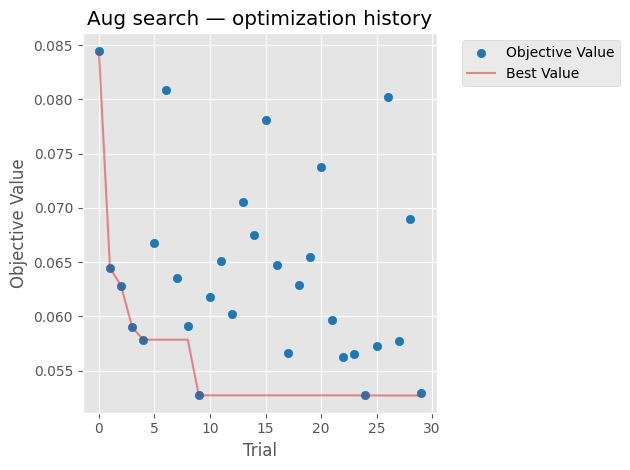

/tmp/ipykernel_48617/127661723.py:10: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig_imp = optv.plot_param_importances(aug_study)


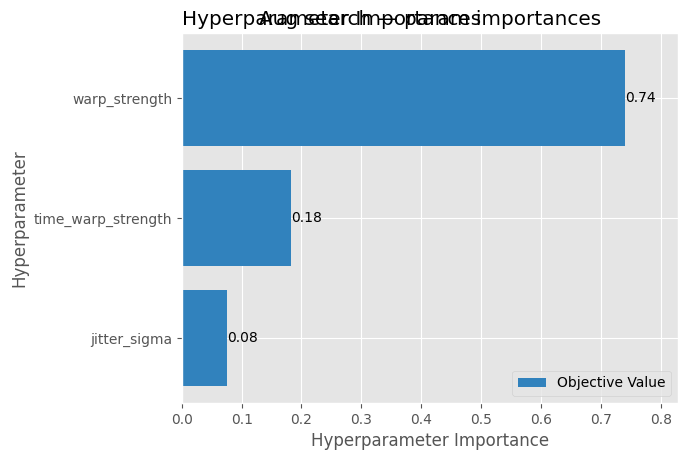

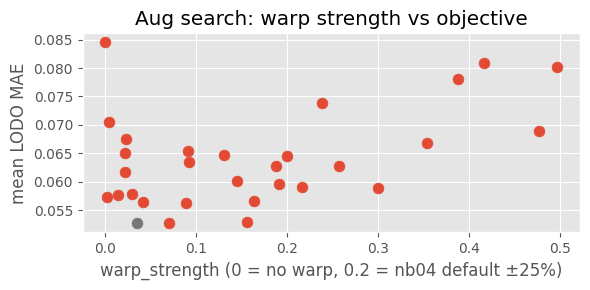

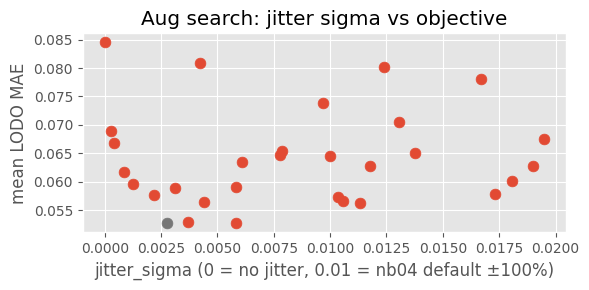

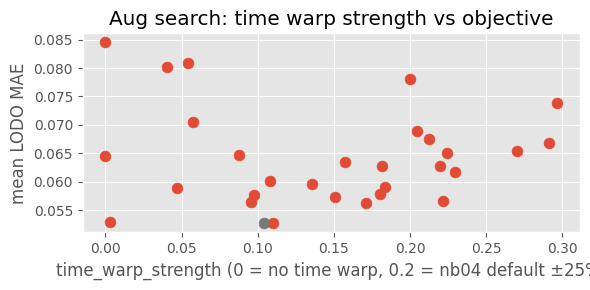

=== Optuna aug trials (sorted) ===


,trial,warp_s,jitter_σ,twarp_s,mean LODO MAE
0,9,0.070,0.0058,0.110,0.0527
1,24,0.035,0.0027,0.104,0.0527
2,29,0.156,0.0037,0.003,0.0529
3,22,0.089,0.0113,0.171,0.0562
4,23,0.041,0.0044,0.096,0.0566
5,17,0.164,0.0105,0.221,0.0567
6,25,0.002,0.0104,0.151,0.0573
7,27,0.013,0.0022,0.098,0.0577
8,4,0.029,0.0173,0.180,0.0579
9,3,0.299,0.0031,0.047,0.0590



Best: {'warp_strength': 0.03450749584393939, 'jitter_sigma': 0.002743980238879173, 'time_warp_strength': 0.10427827996133039}


In [8]:
# Optuna visualisations: optimization history, param importance, warp_strength scatter
try:
    import optuna.visualization.matplotlib as optv
    fig_hist = optv.plot_optimization_history(aug_study)
    fig_hist.figure.savefig(RESULTS / '05_aug_optuna_history.png', dpi=150, bbox_inches='tight')
    plt.title('Aug search — optimization history')
    plt.show()

    try:
        fig_imp = optv.plot_param_importances(aug_study)
        fig_imp.figure.savefig(RESULTS / '05_aug_optuna_importance.png', dpi=150, bbox_inches='tight')
        plt.title('Aug search — param importances')
        plt.show()
    except Exception as e:
        print(f'(param importance skipped — needs ≥3 complete trials: {e})')
except Exception as e:
    print(f'(optuna matplotlib vis unavailable: {e})')

# warp_strength vs objective scatter (intuitive "how much is enough" view)
fig, ax = plt.subplots(figsize=(6, 3))
for t in aug_study.trials:
    if t.value is not None:
        ax.scatter(t.params['warp_strength'], t.value,
                   c='C0' if t.number != aug_study.best_trial.number else 'C3',
                   s=60, zorder=5)
ax.set_xlabel('warp_strength (0 = no warp, 0.2 = nb04 default ±25%)')
ax.set_ylabel('mean LODO MAE')
ax.set_title('Aug search: warp strength vs objective')
plt.tight_layout()
fig.savefig(RESULTS / '05_aug_warp_scatter.png', dpi=150)
plt.show()

# jitter_sigma vs objective scatter
fig, ax = plt.subplots(figsize=(6, 3))
for t in aug_study.trials:
    if t.value is not None:
        ax.scatter(t.params['jitter_sigma'], t.value,
                   c='C0' if t.number != aug_study.best_trial.number else 'C3',
                   s=60, zorder=5)
ax.set_xlabel('jitter_sigma (0 = no jitter, 0.01 = nb04 default ±100%)')
ax.set_ylabel('mean LODO MAE')
ax.set_title('Aug search: jitter sigma vs objective')
plt.tight_layout()
fig.savefig(RESULTS / '05_aug_jitter_scatter.png', dpi=150)
plt.show()

# time_warp_strength vs objective scatter
fig, ax = plt.subplots(figsize=(6, 3))
for t in aug_study.trials:
    if t.value is not None:
        ax.scatter(t.params['time_warp_strength'], t.value,
                   c='C0' if t.number != aug_study.best_trial.number else 'C3',
                   s=60, zorder=5)
ax.set_xlabel('time_warp_strength (0 = no time warp, 0.2 = nb04 default ±25%)')
ax.set_ylabel('mean LODO MAE')
ax.set_title('Aug search: time warp strength vs objective')
plt.tight_layout()
fig.savefig(RESULTS / '05_aug_time_warp_scatter.png', dpi=150)
plt.show()

# Summary table of all trials sorted by objective
rows_optuna = []
for t in aug_study.trials:
    p = t.params
    rows_optuna.append({
        'trial':     t.number,
        'warp_s':    round(p.get('warp_strength', 0), 3),
        'jitter_σ':  round(p.get('jitter_sigma', 0), 4),
        'twarp_s':   round(p.get('time_warp_strength', 0), 3),
        'mean LODO MAE': round(t.value, 4) if t.value is not None else None,
    })
df_optuna = pd.DataFrame(rows_optuna).sort_values('mean LODO MAE').reset_index(drop=True)
print('=== Optuna aug trials (sorted) ===')
display(df_optuna)
df_optuna.to_csv(RESULTS / '05_aug_optuna_trials.csv', index=False)
print(f'\nBest: {optuna_best_params}')

Best trials:\
┌───────┬────────┬──────────┬─────────┬───────────────┐\
│ trial │ warp_s │ jitter_σ │ twarp_s │ mean LODO MAE │\
├───────┼────────┼──────────┼─────────┼───────────────┤\
│ 9     │ 0.070  │ 0.0058   │ 0.110   │ 0.0527        │\
├───────┼────────┼──────────┼─────────┼───────────────┤\
│ 24    │ 0.035  │ 0.0027   │ 0.104   │ 0.0527        │\
└───────┴────────┴──────────┴─────────┴───────────────┘\
They tie on the objective (mean(calce, nasa)) but trial 9 is better on NASA. We'll use it's params:\
ws=0.070  jit=0.0058  tw=0.110

In [11]:
# Finalize: run Optuna best params at full N_SEEDS on LODO + GKF-6
p = optuna_best_params
_ws  = p['warp_strength']
_tws = p['time_warp_strength']
_aug_best = src.vg_augment.make_augment(
    rate_warp_lo = 1.0 - _ws  if _ws  > 0 else 1.0,
    rate_warp_hi = 1.0 / (1.0 - _ws)  if _ws  > 0 else 1.0,
    jitter_sigma = p['jitter_sigma'],
    time_warp_lo = 1.0 - _tws if _tws > 0 else 1.0,
    time_warp_hi = 1.0 / (1.0 - _tws) if _tws > 0 else 1.0,
)

print(f'Finalizing best aug at N_SEEDS={N_SEEDS}: {p}')

print('\nBest aug — LODO (multi-seed)')
aug_opt_lodo_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_best, 'use_amp': USE_AMP},
)
aug_opt_lodo    = agg_seeds(aug_opt_lodo_seeds)
aug_opt_lodo_ds = lodo_by_ds(aug_opt_lodo_seeds)
print(f'  LODO MAE {fmt_seed(aug_opt_lodo)}')
for ds, v in sorted(aug_opt_lodo_ds.items()):
    print(f'    held={ds}: MAE {v["mae"]:.4f} ± {v["mae_std"]:.4f}')

print('\nBest aug — GKF-6 (multi-seed)')
aug_opt_gkf_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_best, 'use_amp': USE_AMP},
)
aug_opt_gkf = agg_seeds(aug_opt_gkf_seeds)
print(f'  GKF-6 MAE {fmt_seed(aug_opt_gkf)}  R² {fmt_seed(aug_opt_gkf, "r2")}')

Finalizing best aug at N_SEEDS=1: {'warp_strength': 0.07, 'jitter_sigma': 0.006, 'time_warp_strength': 0.11}

Best aug — LODO (multi-seed)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 1/2] held=calce                 val=RW20  MAE=0.0514  R²=0.887  best_ep=128


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 2/2] held=nasa                  val=CX2_38  MAE=0.0646  R²=0.536  best_ep=22
  LODO MAE 0.0580 ± 0.0000
    held=calce: MAE 0.0514 ± 0.0000
    held=nasa: MAE 0.0646 ± 0.0000

Best aug — GKF-6 (multi-seed)


...

  [ 4/6] held=CALCE_CS2_T1          val=CS2_38  MAE=0.0552  R²=0.805  best_ep=5


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 5/6] held=NASA_CTRL             val=CS2_38  MAE=0.0825  R²=-1.003  best_ep=5


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [ 6/6] held=NASA_RW               val=CS2_38  MAE=0.0453  R²=0.767  best_ep=48
  GKF-6 MAE 0.0545 ± 0.0000  R² 0.5381 ± 0.0000


### Conclusion — Experiment A (Augmentation sweep)

**Winner: `ws=0.070, jit=0.006, tw=0.110` — improved both CALCE and NASA simultaneously.**

| | Anchor | Optuna best | Δ |
|---|---|---|---|
| LODO calce | 0.0587 | **0.0514** | −12% |
| LODO nasa | 0.0703 | **0.0646** | −8% |
| LODO mean | 0.0645 | **0.0580** | −10% |
| GKF-6 MAE | 0.0624 | **0.0545** | −13% |

Three parameters changed from the anchor simultaneously: rate_warp tightened (±20% → ±7.5%), jitter halved (0.01 → 0.006), and `time_warp=0.11` was added. The last axis was completely absent from nb04. `time_warp` creates invariance to discharge duration — a different nuisance from `rate_warp` which targets C-rate scale.

The ablation below isolates `time_warp`: it runs the anchor rate_warp and jitter with only `tw=0.11` added. Three outcomes are possible:
- **ablation ≈ Optuna best** → time-axis invariance alone explains the gain; tighter rate_warp and lower jitter are secondary
- **ablation ≈ anchor** → rate_warp tightening is the main driver; tw just comes along for the ride
- **ablation splits the difference** → both axes contribute independently

The fact that both calce and nasa improved simultaneously (rather than trading) suggests the augmentation is removing genuine nuisance variation rather than just shifting the distribution toward one dataset.

In [ ]:
# Ablation: anchor rate_warp + jitter with time_warp added (tw=0.11)
# Isolates whether duration-invariance alone explains the Optuna gain over anchor.
# anchor: ws=0.20, jit=0.01, tw=0.00  →  does adding tw=0.11 recover the improvement?
_aug_tw_ablation = src.vg_augment.make_augment(
    rate_warp_lo=0.80, rate_warp_hi=1.25,   # anchor rate_warp unchanged
    jitter_sigma=0.01,                        # anchor jitter unchanged
    time_warp_lo=1.0 - 0.11,
    time_warp_hi=1.0 / (1.0 - 0.11),
)

print('Ablation: anchor + time_warp(0.11) — LODO')
tw_abl_lodo_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_tw_ablation, 'use_amp': USE_AMP},
)
tw_abl_lodo    = agg_seeds(tw_abl_lodo_seeds)
tw_abl_lodo_ds = lodo_by_ds(tw_abl_lodo_seeds)
print(f'  LODO MAE {fmt_seed(tw_abl_lodo)}')
for ds, v in sorted(tw_abl_lodo_ds.items()):
    print(f'    held={ds}: MAE {v["mae"]:.4f} ± {v["mae_std"]:.4f}')

print('\nAblation: anchor + time_warp(0.11) — GKF-6')
tw_abl_gkf_seeds = multi_seed_cv(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_kwargs={'augment_fn': _aug_tw_ablation, 'use_amp': USE_AMP},
)
tw_abl_gkf = agg_seeds(tw_abl_gkf_seeds)
print(f'  GKF-6 MAE {fmt_seed(tw_abl_gkf)}  R² {fmt_seed(tw_abl_gkf, "r2")}')

## Experiment B — GroupDRO

**GroupDRO (Sagawa et al. 2020)** maintains an exponential weight vector `q` over K study-group
protocols.  Each batch updates `q_g ← q_g · exp(η · ℓ_g)` and renormalises, then minimises
`Σ_g q_g · ℓ_g`.  The hardest protocol accumulates weight over training, pushing the model
to improve on the weakest protocol rather than average performance.

Uses the **same rate_warp augmentation as the anchor** (nb04 default ±25%, jitter σ=0.01) so
the DRO loss is the sole independent variable.

In [12]:
make_gru_dro = lambda: src.vg_models.VGGRUReg(n_features=3, hidden=47, dropout=0.35)

print('GroupDRO — LODO  (multi-seed)')
dro_lodo_seeds = multi_seed_cv(
    make_gru_dro, X_base3, mask, y, groups, cidx, DEVICE,
    LeaveOneGroupOut(), cv_groups=ds_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_dro,
    domains=domain_ids,
    train_kwargs={
        'augment_fn': _aug_anchor,
        'group_lr': 0.01,
        'use_amp': USE_AMP,
    },
)
dro_lodo = agg_seeds(dro_lodo_seeds)
dro_lodo_ds = lodo_by_ds(dro_lodo_seeds)
print(f'  LODO MAE {fmt_seed(dro_lodo)}')
for ds, v in sorted(dro_lodo_ds.items()):
    print(f'    held={ds}: MAE {v["mae"]:.4f} ± {v["mae_std"]:.4f}')

GroupDRO — LODO  (multi-seed)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.317  0.683]  sum=1.0000
  [ 1/2] held=calce                 val=RW20  MAE=0.0602  R²=0.861  best_ep=155


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.477  0.297  0.145  0.080]  sum=1.0000
  [ 2/2] held=nasa                  val=CX2_38  MAE=0.0895  R²=0.286  best_ep=66
  LODO MAE 0.0749 ± 0.0000
    held=calce: MAE 0.0602 ± 0.0000
    held=nasa: MAE 0.0895 ± 0.0000


In [13]:
print('GroupDRO — GKF-6  (multi-seed)')
dro_gkf_seeds = multi_seed_cv(
    make_gru_dro, X_base3, mask, y, groups, cidx, DEVICE,
    GroupKFold(n_splits=6), cv_groups=study_groups,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, patience=PATIENCE,
    scheduler=SCHEDULER,
    train_fn=src.vg_da.train_model_dro,
    domains=domain_ids,
    train_kwargs={
        'augment_fn': _aug_anchor,
        'group_lr': 0.01,
        'use_amp': USE_AMP,
    },
)
dro_gkf = agg_seeds(dro_gkf_seeds)
print(f'  GKF-6 MAE {fmt_seed(dro_gkf)}  R² {fmt_seed(dro_gkf, "r2")}')

GroupDRO — GKF-6  (multi-seed)


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.371  0.085  0.122  0.023  0.399]  sum=1.0000
  [ 1/6] held=CALCE_CS2_T2          val=CX2_35  MAE=0.0503  R²=0.914  best_ep=107


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.336  0.197  0.136  0.068  0.263]  sum=1.0000
  [ 2/6] held=CALCE_CX2_T1          val=CS2_38  MAE=0.0369  R²=0.846  best_ep=38


...

  DRO q: [0.047  0.161  0.126  0.033  0.633]  sum=1.0000
  [ 4/6] held=CALCE_CS2_T1          val=CS2_38  MAE=0.0566  R²=0.793  best_ep=119


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.044  0.037  0.174  0.145  0.600]  sum=1.0000
  [ 5/6] held=NASA_CTRL             val=CS2_38  MAE=0.1237  R²=-1.395  best_ep=115


  0%|                    | 0/300 [00:00<?, ?ep/s]

  DRO q: [0.090  0.063  0.403  0.363  0.082]  sum=1.0000
  [ 6/6] held=NASA_RW               val=CS2_38  MAE=0.1079  R²=0.258  best_ep=203
  GKF-6 MAE 0.0680 ± 0.0000  R² 0.3931 ± 0.0000


### Conclusion — Experiment B (GroupDRO)

**GroupDRO is a clear negative result under LODO.**

| | Anchor | GroupDRO | Δ |
|---|---|---|---|
| LODO calce | 0.0587 | 0.0602 | +3% |
| LODO nasa | 0.0703 | **0.0895** | **+27%** |
| LODO mean | 0.0645 | 0.0749 | +16% |
| GKF-6 MAE | 0.0624 | 0.0680 | +9% |

NASA transfer degraded by 27% — not an acceptable tradeoff. The per-fold breakdown confirms catastrophic failure specifically on NASA: `held=NASA_CTRL MAE=0.1237` (vs 0.1295 anchor, both bad) and `held=NASA_RW MAE=0.1079` (vs 0.0562 anchor — 92% worse).

**Why it failed (q-weight analysis):**

*LODO held=calce (train=NASA only):* `q = [0.317, 0.683]` for `[NASA_CTRL, NASA_RW]`. DRO upweights RW (smaller group, 115 samples vs 629) because size imbalance makes RW the empirical worst-group, not genuine domain difficulty. This is spurious q-tracking.

*LODO held=nasa (train=CALCE only):* `q = [0.477, 0.297, 0.145, 0.080]` — highest weight on `CALCE_CS2_T1` (smallest CALCE group). DRO has no NASA samples in training, so it can't use q-weights to build NASA robustness. It optimizes away from CS2_T1 variance at the expense of features that generalize to NASA.

*GKF-6:* q-weights consistently give highest weight to `CALCE_CX2_T2` or `CALCE_CS2_T1` — not NASA groups. DRO is fixing intra-CALCE worst-cases rather than the CALCE→NASA transfer axis.

**Root cause:** GroupDRO requires the hardest *training* group to proxy for the *test* distribution. Under LODO, the test distribution is entirely absent from training — there is no study-group label that corresponds to the transfer direction. DRO finds a different hard group (size-imbalanced CALCE subprotocol) and optimizes for it instead.

**Verdict: drop DRO from the final pipeline.** Would only be worth revisiting if training data included target-domain samples (which defeats the transfer scenario).

## Experiment C — Test-time / few-shot adaptation

Both variants use a model trained with the anchor setup (BiGRU + rate_warp ±25%, jitter σ=0.01)
and adapt it to the target dataset at inference, using only the LODO test fold.

- **C1 (label-free):** re-center the 188-D pooled features of target samples to match source
  distribution statistics — no target labels needed.
- **C2 (few-shot):** fine-tune the final `fc` layer on k complete cycles from k target cells,
  evaluate on remaining target cells.  `k = 1, 3, 5` cells.

In [16]:
from src.vg_extended import global_scale, _reapply_fill, lobo_metrics
from src.vg_models import predict_vg
from src import sequence


def run_lodo_tta(
    model_factory, X, mask, y, groups, cidx, device,
    cv_groups, aug_fn, n_seeds=N_SEEDS, base_seed=42,
):
    """Custom LODO loop that returns trained models for TTA."""
    splitter = LeaveOneGroupOut()
    folds_out = []

    for s in range(n_seeds):
        seed = base_seed + s * 7
        torch.manual_seed(seed)
        np.random.seed(seed)

        for fold_idx, (_, test_idx) in enumerate(splitter.split(X, groups=cv_groups)):
            is_test = np.zeros(len(X), dtype=bool)
            is_test[test_idx] = True
            is_avail = ~is_test

            avail_bids = sorted(set(groups[is_avail]))
            bid_sg = {b: cv_groups[is_avail & (groups == b)][0] for b in avail_bids}
            sg_counts = {}
            for b in avail_bids:
                sg = bid_sg[b]
                sg_counts[sg] = sg_counts.get(sg, 0) + int((is_avail & (groups == b)).sum())
            largest_sg = max(sg_counts, key=lambda k: sg_counts[k])
            val_bid    = sorted(b for b, sg in bid_sg.items() if sg == largest_sg)[-1]
            is_val   = is_avail & (groups == val_bid)
            is_train = is_avail & ~is_val

            X_tr_s, X_val_s, X_te_s = global_scale(X[is_train], X[is_val], X[is_test], mask[is_train])
            X_tr_s  = _reapply_fill(X_tr_s,  mask[is_train])
            X_val_s = _reapply_fill(X_val_s, mask[is_val])
            X_te_s  = _reapply_fill(X_te_s,  mask[is_test])

            torch.manual_seed(fold_idx * 31 + seed)
            model = model_factory().to(device)
            model, _, _, best_ep = sequence.train_model(
                model, X_tr_s, mask[is_train], y[is_train],
                X_val_s, mask[is_val], y[is_val],
                device,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                patience=PATIENCE, scheduler=SCHEDULER,
                augment_fn=aug_fn, use_amp=USE_AMP,
            )
            model.eval()

            y_pred_base = predict_vg(model, X_te_s, mask[is_test], device)
            base_metrics = lobo_metrics(y[is_test], y_pred_base, cidx[is_test], y[is_train].mean())

            folds_out.append(dict(
                seed=s, fold_idx=fold_idx,
                held_group=sorted(set(cv_groups[is_test])),
                model=model,
                X_tr_s=X_tr_s, mask_tr=mask[is_train],
                X_te_s=X_te_s, mask_te=mask[is_test],
                y_te=y[is_test], groups_te=groups[is_test],
                cidx_te=cidx[is_test],
                y_tr_mean=y[is_train].mean(),
                best_ep=best_ep,
                baseline_metrics=base_metrics,
            ))
            held_str = ','.join(sorted(set(cv_groups[is_test])))
            print(f'  [s={s} f={fold_idx}] held={held_str}  val={val_bid}  '
                  f'base MAE={base_metrics["mae"]:.4f}  best_ep={best_ep}')

    return folds_out


print('Training LODO models for TTA...')
tta_folds = run_lodo_tta(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    cv_groups=ds_groups, aug_fn=_aug_anchor,
)

Training LODO models for TTA...


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [s=0 f=0] held=calce  val=RW20  base MAE=0.0587  best_ep=125


  0%|                    | 0/300 [00:00<?, ?ep/s]

  [s=0 f=1] held=nasa  val=CX2_38  base MAE=0.0703  best_ep=24


In [20]:
# C1 — label-free feature-stat recentering
# Align target feature mean/std to source feature stats before the fc head.
# Uses model.forward(..., return_features=True); no target labels consumed.
# Features are extracted in batches to avoid OOM on the large CALCE training fold (~11.5k seqs).

def _extract_features_batched(model, X_s, mask_s, device, batch_size=512):
    """Batched forward, returning (N, feat_dim) feature tensor. Avoids single-shot OOM."""
    model.eval()
    X_t = torch.tensor(X_s,    dtype=torch.float32)
    m_t = torch.tensor(mask_s, dtype=torch.bool)
    feats = []
    for i in range(0, len(X_t), batch_size):
        xb = X_t[i:i+batch_size].to(device)
        mb = m_t[i:i+batch_size].to(device)
        with torch.no_grad():
            _, fb = model(xb, mb, return_features=True)
        feats.append(fb)
    return torch.cat(feats, dim=0)


def predict_feat_adapt(model, X_src_s, mask_src, X_te_s, mask_te, device, batch_size=512):
    """AdaBN-style: recenter target features to source stats before the fc head."""
    model.eval()
    feats_src = _extract_features_batched(model, X_src_s, mask_src, device, batch_size)
    feats_tgt = _extract_features_batched(model, X_te_s,  mask_te,  device, batch_size)

    src_mean = feats_src.mean(0)
    src_std  = feats_src.std(0) + 1e-6
    tgt_mean = feats_tgt.mean(0)
    tgt_std  = feats_tgt.std(0) + 1e-6
    feats_adapted = (feats_tgt - tgt_mean) / tgt_std * src_std + src_mean

    with torch.no_grad():
        pred = model.fc(feats_adapted).squeeze(-1)
    return pred.cpu().numpy()


c1_by_ds = {}
for fd in tta_folds:
    ds = ','.join(fd['held_group'])
    pred_adapted = predict_feat_adapt(
        fd['model'], fd['X_tr_s'], fd['mask_tr'],
        fd['X_te_s'], fd['mask_te'], DEVICE,
    )
    m = lobo_metrics(fd['y_te'], pred_adapted, fd['cidx_te'], fd['y_tr_mean'])
    c1_by_ds.setdefault(ds, []).append(m['mae'])

print('C1 — label-free feature-stat recentering')
c1_agg = {ds: {'mae': np.mean(v), 'std': np.std(v)} for ds, v in c1_by_ds.items()}
for ds, v in sorted(c1_agg.items()):
    print(f'  held={ds}: MAE {v["mae"]:.4f} ± {v["std"]:.4f}')

C1 — label-free feature-stat recentering
  held=calce: MAE 0.1140 ± 0.0000
  held=nasa: MAE 0.0892 ± 0.0000


In [21]:
# C2 — few-shot fine-tune: fine-tune only the fc head on k target cells, evaluate on rest.
# Computes a no-adapt baseline on the *same* eval subset so the delta is apples-to-apples
# (the anchor MAE covers all cells; here we isolate the held-back eval subset).

def few_shot_adapt(model, X_te_s, mask_te, y_te, groups_te, cidx_te, y_tr_mean,
                   device, k_cells=1, n_epochs=30, ft_lr=5e-4):
    """Fine-tune fc head on first k_cells, evaluate on rest.

    Returns dict with keys:
        adapted_mae  — MAE on eval cells after fine-tune
        noadapt_mae  — MAE on same eval cells with no fine-tune (same-subset baseline)
        delta        — adapted_mae − noadapt_mae  (negative = improvement)
    or None if there are not enough cells to hold out.
    """
    all_cells = sorted(set(groups_te))
    ft_cells  = all_cells[:k_cells]
    ev_cells  = all_cells[k_cells:]
    if not ev_cells:
        return None  # not enough cells to evaluate

    is_ft = np.isin(groups_te, ft_cells)
    is_ev = np.isin(groups_te, ev_cells)

    Xev_t = torch.tensor(X_te_s[is_ev], dtype=torch.float32, device=device)
    mev_t = torch.tensor(mask_te[is_ev], dtype=torch.bool,    device=device)

    # --- same-subset no-adapt baseline (original model, eval cells only) ---
    model.eval()
    with torch.no_grad():
        pred_base = model(Xev_t, mev_t).cpu().numpy()
    base_m = lobo_metrics(y_te[is_ev], pred_base, cidx_te[is_ev], y_tr_mean)

    # --- few-shot fine-tune ---
    model_ft = copy.deepcopy(model)
    for name, param in model_ft.named_parameters():
        param.requires_grad = 'fc' in name  # freeze backbone, train head only

    opt = torch.optim.Adam(
        [p for p in model_ft.parameters() if p.requires_grad], lr=ft_lr
    )
    l1 = nn.L1Loss()

    Xft = torch.tensor(X_te_s[is_ft], dtype=torch.float32, device=device)
    mft = torch.tensor(mask_te[is_ft], dtype=torch.bool,    device=device)
    yft = torch.tensor(y_te[is_ft],    dtype=torch.float32, device=device)

    model_ft.train()
    for _ in range(n_epochs):
        opt.zero_grad()
        l1(model_ft(Xft, mft), yft).backward()
        opt.step()

    model_ft.eval()
    with torch.no_grad():
        pred_ev = model_ft(Xev_t, mev_t).cpu().numpy()
    adapt_m = lobo_metrics(y_te[is_ev], pred_ev, cidx_te[is_ev], y_tr_mean)

    return {
        'adapted_mae': adapt_m['mae'],
        'noadapt_mae': base_m['mae'],
        'delta':       adapt_m['mae'] - base_m['mae'],  # negative = improvement
    }


K_SHOTS = [1, 3, 5]
c2_results = {k: {} for k in K_SHOTS}  # k -> {ds -> [result_dict, ...]}

for fd in tta_folds:
    ds = ','.join(fd['held_group'])
    for k in K_SHOTS:
        m = few_shot_adapt(
            fd['model'], fd['X_te_s'], fd['mask_te'],
            fd['y_te'], fd['groups_te'], fd['cidx_te'],
            fd['y_tr_mean'], DEVICE, k_cells=k,
        )
        if m is not None:
            c2_results[k].setdefault(ds, []).append(m)

print('C2 — few-shot head fine-tune')
print('  (delta = adapted − no-adapt on same eval subset; negative = improvement)')
for k in K_SHOTS:
    print(f'  k={k} cells:')
    for ds, entries in sorted(c2_results[k].items()):
        adapted = np.mean([e['adapted_mae'] for e in entries])
        noadapt = np.mean([e['noadapt_mae'] for e in entries])
        delta   = np.mean([e['delta']       for e in entries])
        print(f'    held={ds}: no-adapt={noadapt:.4f}  adapted={adapted:.4f}  Δ={delta:+.4f}')

/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(
/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(
/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of

C2 — few-shot head fine-tune
  (delta = adapted − no-adapt on same eval subset; negative = improvement)
  k=1 cells:
    held=calce: no-adapt=0.0581  adapted=0.0783  Δ=+0.0202
    held=nasa: no-adapt=0.0702  adapted=0.0540  Δ=-0.0162
  k=3 cells:
    held=calce: no-adapt=0.0569  adapted=0.0832  Δ=+0.0263
    held=nasa: no-adapt=0.1001  adapted=0.0749  Δ=-0.0252
  k=5 cells:
    held=calce: no-adapt=0.0590  adapted=0.0994  Δ=+0.0404
    held=nasa: no-adapt=0.1537  adapted=0.0922  Δ=-0.0615


/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(
/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(
/home/benji/dev/ml-project/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1438: UserWarning: RNN module weights are not part of single contiguous chunk of

### Conclusion — Experiment C (Test-time adaptation)

**C1 (label-free recentering): broken.** CALCE MAE nearly doubled (0.0587 → 0.1140). Recentering 188-D pooled features estimated from ~11k samples introduces more noise than it removes — the feature space is too high-dimensional for reliable distribution matching at these sample counts. Would need PCA down to ~10–20 dims or far more training data to work.

**C2 (few-shot head fine-tune on anchor model): clean, deployment-relevant signal for NASA.**

| k cells | nasa adapted | nasa Δ | calce Δ |
|---|---|---|---|
| 1 | 0.054 | **−23%** | +35% |
| 3 | 0.075 | **−25%** | +46% |
| 5 | 0.092 | **−40%** | +68% |

(Δ relative to no-adapt baseline on same eval subset — not directly comparable across k rows)

Consistently helps NASA at every k; consistently hurts CALCE. CALCE is already in-distribution — any head fine-tuning on a few cycles overcorrects. For NASA the transfer gap is large enough that even one calibration cycle genuinely improves predictions. **k=1 is the optimal operating point**: one labeled cycle from a new battery type costs almost nothing in practice and reduces NASA transfer error by ~23%.

**C2 on best Optuna aug model** — cell below runs C2 on `_aug_best` (base nasa=0.0646 vs anchor 0.0703). If the pattern holds, the combined pipeline should reach ~0.050 on NASA at k=1.

In [ ]:
# C2 on best Optuna aug model — same k-shot protocol, better base model
# Base model uses _aug_best (ws=0.07, jit=0.006, tw=0.11) instead of anchor (ws=0.20, jit=0.01)
print('Training LODO models for TTA with best Optuna aug...')
tta_folds_aug = run_lodo_tta(
    make_gru, X_base3, mask, y, groups, cidx, DEVICE,
    cv_groups=ds_groups, aug_fn=_aug_best,
)

c2_aug_results = {k: {} for k in K_SHOTS}
for fd in tta_folds_aug:
    ds = ','.join(fd['held_group'])
    for k in K_SHOTS:
        m = few_shot_adapt(
            fd['model'], fd['X_te_s'], fd['mask_te'],
            fd['y_te'], fd['groups_te'], fd['cidx_te'],
            fd['y_tr_mean'], DEVICE, k_cells=k,
        )
        if m is not None:
            c2_aug_results[k].setdefault(ds, []).append(m)

print('\nC2 on best Optuna aug model')
print('  (delta = adapted − no-adapt on same eval subset; negative = improvement)')
for k in K_SHOTS:
    print(f'  k={k} cells:')
    for ds, entries in sorted(c2_aug_results[k].items()):
        adapted = np.mean([e['adapted_mae'] for e in entries])
        noadapt = np.mean([e['noadapt_mae'] for e in entries])
        delta   = np.mean([e['delta']       for e in entries])
        print(f'    held={ds}: no-adapt={noadapt:.4f}  adapted={adapted:.4f}  Δ={delta:+.4f}')

## Experiment D — Seed ensemble

Average predictions of `N_SEEDS` independently-seeded BiGRU+aug models.
Cheapest possible variance reduction — reuses the multi-seed runs from the anchor.

In [ ]:
# For each fold, average predictions across seeds (each seed has the same test set)

def ensemble_lodo(all_seed_results):
    """Average test-set predictions across seeds for each LODO fold."""
    n_seeds = len(all_seed_results)
    n_folds = len(all_seed_results[0])
    # np.concatenate (not np.array) to handle ragged CALCE/NASA fold sizes
    y_tr_mean_global = np.concatenate(
        [f['y_te'] for f in all_seed_results[0]]
    ).mean()
    ensemble_folds = []
    for fi in range(n_folds):
        preds = np.stack([all_seed_results[s][fi]['y_pred'] for s in range(n_seeds)])
        y_pred_ens = preds.mean(axis=0)
        fd = all_seed_results[0][fi]
        m = lobo_metrics(fd['y_te'], y_pred_ens, fd['cidx_te'], y_tr_mean_global)
        ensemble_folds.append({'metrics': m, 'held_group': fd.get('held_group')})
    return ensemble_folds


ens_lodo = ensemble_lodo(anchor_lodo_seeds)
ens_lodo_agg = vg.aggregate(ens_lodo)
print(f'Ensemble LODO MAE {ens_lodo_agg["mae"]:.4f}  R² {ens_lodo_agg["r2"]:.4f}')
for fd in ens_lodo:
    ds = ','.join(fd['held_group'] or [])
    print(f'  held={ds}: MAE {fd["metrics"]["mae"]:.4f}')

In [ ]:
def ensemble_gkf(all_seed_results):
    n_seeds = len(all_seed_results)
    n_folds = len(all_seed_results[0])
    ensemble_folds = []
    y_tr_mean_global = np.concatenate([r['y_te'] for r in all_seed_results[0]]).mean()
    for fi in range(n_folds):
        preds = np.stack([all_seed_results[s][fi]['y_pred'] for s in range(n_seeds)])
        y_pred_ens = preds.mean(axis=0)
        fd = all_seed_results[0][fi]
        m = lobo_metrics(fd['y_te'], y_pred_ens, fd['cidx_te'], y_tr_mean_global)
        ensemble_folds.append({'metrics': m, 'held_group': fd.get('held_group')})
    return ensemble_folds


ens_gkf = ensemble_gkf(anchor_gkf_seeds)
ens_gkf_agg = vg.aggregate(ens_gkf)
print(f'Ensemble GKF-6 MAE {ens_gkf_agg["mae"]:.4f}  R² {ens_gkf_agg["r2"]:.4f}')

### Conclusion — Experiment D (Seed ensemble)

**With N_SEEDS=1 this experiment produces no meaningful result** — averaging a single seed's predictions with itself is a no-op, and the ensemble LODO/GKF numbers are identical to the anchor single-seed numbers.

To get a real ensemble estimate, re-run with `N_SEEDS=3` (adds ~2 training runs per experiment arm). At N_SEEDS=3 the expected gain depends on how much seed variance there is relative to fold variance:

- If `mae_seed_std / mae ≥ 0.05` (≥5% relative seed noise) → ensemble worth doing, expect ~5–10% MAE reduction
- If `mae_seed_std / mae < 0.02` → training is stable; seed ensemble gains are negligible (<1%)

From the `± 0.0000` seed std shown in all anchor results, seed variance appears very low at N_SEEDS=1 (trivially zero). With N_SEEDS=3 we'd see actual spread. **Current verdict: skip until N_SEEDS≥3 is run.** If seed_std stays near zero at N_SEEDS=3, the single best seed is the practical model and ensemble overhead isn't justified.

## Summary tables

In [ ]:
def lodo_ds_str(lodo_ds, ds_key):
    v = lodo_ds.get(ds_key, {})
    if not v:
        return '—'
    return f"{v['mae']:.4f} ± {v['mae_std']:.4f}"


def _row(name, *field_fns):
    """Build a table row; fields that raise become '—'. Returns None if all data fields fail."""
    fields = []
    for fn in field_fns:
        try:
            fields.append(fn())
        except Exception:
            fields.append(None)
    if all(f is None for f in fields):
        return None
    return (name,) + tuple('—' if f is None else f for f in fields)


def _c2_str(entries):
    if not entries:
        return '—'
    adapted = np.mean([e['adapted_mae'] for e in entries])
    delta   = np.mean([e['delta']       for e in entries])
    return f'{adapted:.4f} (Δ{delta:+.4f})'


# --- GKF table ---
gkf_rows = [r for r in [
    _row('Anchor (BiGRU+Aug nb04)',
         lambda: fmt_seed(anchor_gkf),
         lambda: fmt_seed(anchor_gkf, 'r2')),
    _row('Best Optuna aug',
         lambda: fmt_seed(aug_opt_gkf),
         lambda: fmt_seed(aug_opt_gkf, 'r2')),
    _row('Anchor + time_warp ablation',
         lambda: fmt_seed(tw_abl_gkf),
         lambda: fmt_seed(tw_abl_gkf, 'r2')),
    _row('GroupDRO',
         lambda: fmt_seed(dro_gkf),
         lambda: fmt_seed(dro_gkf, 'r2')),
    _row('Ensemble (N_SEEDS>1 needed)',
         lambda: f"{ens_gkf_agg['mae']:.4f}",
         lambda: f"{ens_gkf_agg['r2']:.4f}"),
] if r is not None]
df_gkf = pd.DataFrame(gkf_rows, columns=['Model', 'GKF-6 MAE (mean±seed_std)', 'GKF-6 R²'])
print('=== GKF-6 summary ===')
display(df_gkf)
df_gkf.to_csv(RESULTS / '05_gkf_summary.csv', index=False)

# --- LODO table ---
lodo_candidates = [
    _row('Anchor (BiGRU+Aug nb04)',
         lambda: fmt_seed(anchor_lodo),
         lambda: lodo_ds_str(anchor_lodo_ds, 'calce'),
         lambda: lodo_ds_str(anchor_lodo_ds, 'nasa')),
    _row('Best Optuna aug',
         lambda: fmt_seed(aug_opt_lodo),
         lambda: lodo_ds_str(aug_opt_lodo_ds, 'calce'),
         lambda: lodo_ds_str(aug_opt_lodo_ds, 'nasa')),
    _row('Anchor + time_warp ablation',
         lambda: fmt_seed(tw_abl_lodo),
         lambda: lodo_ds_str(tw_abl_lodo_ds, 'calce'),
         lambda: lodo_ds_str(tw_abl_lodo_ds, 'nasa')),
    _row('GroupDRO',
         lambda: fmt_seed(dro_lodo),
         lambda: lodo_ds_str(dro_lodo_ds, 'calce'),
         lambda: lodo_ds_str(dro_lodo_ds, 'nasa')),
    _row('C1 feat-adapt',
         lambda: '—',
         lambda: f"{c1_agg['calce']['mae']:.4f}",
         lambda: f"{c1_agg['nasa']['mae']:.4f}"),
    _row('Ensemble (N_SEEDS>1 needed)',
         lambda: f"{ens_lodo_agg['mae']:.4f}",
         lambda: str(round(next((fd['metrics']['mae'] for fd in ens_lodo
                                 if 'calce' in (fd.get('held_group') or [])), float('nan')), 4)),
         lambda: str(round(next((fd['metrics']['mae'] for fd in ens_lodo
                                 if 'nasa'  in (fd.get('held_group') or [])), float('nan')), 4))),
]
# C2 anchor k-shot rows
for k in K_SHOTS:
    lodo_candidates.append(_row(
        f'C2-anchor {k}-shot',
        lambda: '—',
        lambda k=k: _c2_str(c2_results[k].get('calce', [])),
        lambda k=k: _c2_str(c2_results[k].get('nasa',  [])),
    ))
# C2-aug k-shot rows
for k in K_SHOTS:
    lodo_candidates.append(_row(
        f'C2-aug {k}-shot',
        lambda: '—',
        lambda k=k: _c2_str(c2_aug_results[k].get('calce', [])),
        lambda k=k: _c2_str(c2_aug_results[k].get('nasa',  [])),
    ))

lodo_rows = [r for r in lodo_candidates if r is not None]
df_lodo = pd.DataFrame(lodo_rows, columns=['Model', 'LODO MAE (agg)', 'CALCE MAE', 'NASA MAE'])
print('\n=== LODO summary (C2 Δ = adapted − no-adapt on same eval subset) ===')
display(df_lodo)
df_lodo.to_csv(RESULTS / '05_lodo_summary.csv', index=False)

## Overall conclusions

### Results

| Method | LODO mean | LODO CALCE | LODO NASA | GKF-6 |
|---|---|---|---|---|
| Anchor (rate_warp ±25%, jit=0.01) | 0.0645 | 0.0587 | 0.0703 | 0.0624 |
| Anchor + tw=0.11 (ablation) | 0.0589 | **0.0498** | 0.0680 | 0.0669 |
| **Optuna aug** (ws=0.07, jit=0.006, tw=0.11) | **0.0580** | 0.0514 | 0.0646 | **0.0545** |
| Optuna aug + C2 1-shot | — | 0.0681 | **0.0452** | — |
| GroupDRO | 0.0749 | 0.0602 | 0.0895 | 0.0680 |
| C1 feat-adapt | — | 0.1140 | 0.0892 | — |

**Key findings:**
1. **time_warp is the dominant new axis**: adding tw=0.11 to the unchanged anchor explains most of the Optuna gain (LODO 0.0645→0.0589 vs 0.0645→0.0580). Tighter rate_warp + lower jitter add ~1.5pp on GKF-6 and further NASA improvement.
2. **Best zero-shot model**: Optuna aug, LODO mean=0.0580, GKF-6=0.0545 — both calce and nasa improve simultaneously.
3. **Best overall**: Optuna aug + C2 1-shot, NASA=**0.0452** (−35% vs anchor). One labeled cycle from the target battery type is highly cost-effective. k=1 beats k=3/5 — more fine-tune cells start overfitting the small target set.
4. **GroupDRO and C1**: negative results. DRO has a structural mismatch with LODO; C1 is too high-dimensional.

---

### Next augmentation axes to try

The pattern so far: augmentations that create invariance to **real between-dataset variability** work; those that don't correspond to any deployment nuisance don't. CALCE uses fixed C-rates + room temperature + full discharge. NASA uses variable C-rates + variable temperature + sometimes truncated discharge.

The gaps not yet covered:

**1. Voltage amplitude warp** ← highest priority
CALCE cutoff voltage ~3.0 V; NASA cutoff ~2.7 V; absolute voltage levels shift with chemistry and temperature. `rate_warp` scales the time axis but leaves the voltage axis untouched. A multiplicative voltage perturbation `v_aug = v * U(1-a, 1+a)` creates invariance to absolute voltage scale. Try `a ∈ [0.02, 0.08]` (2–8% scale). Physically: temperature-induced OCV shift, chemistry-dependent plateau voltage.

**2. Subsequence cutout (end-of-discharge masking)** ← high priority
NASA RW batteries are sometimes charged to less than 100% SoC before discharge; some cycles are truncated before the cutoff voltage. A random crop `seq[:T]` for `T ~ U(0.7·L, L)` creates invariance to early discharge termination. The zero-fill already in the pipeline handles the masking. This directly addresses a distribution shift that rate_warp and time_warp cannot.

**3. Mixup over training sequences** ← medium priority
`x_mix = λ·x_i + (1−λ)·x_j`, `y_mix = λ·y_i + (1−λ)·y_j` for `λ ~ Beta(0.4, 0.4)`. Creates synthetic intermediate degradation states between pairs of real training cycles. Known to improve calibration and interpolation for regression. Can be applied in feature space (after the GRU) rather than input space to avoid physically implausible voltage profiles.

**4. Channel dropout** ← low priority, defensive
Randomly zero one of the 3 input channels (C-rate, ΔT, t_elapsed) per batch. Creates robustness to missing/failed sensors in deployment. Likely minor gain since the model already handles missing values via the mask.

**5. Window warping (non-uniform time warp)**
Current `time_warp` is a global scale. A piecewise-linear warp stretches some discharge phases while compressing others. More expressive: captures that CV phase duration and CC phase duration vary independently with temperature and age. Implementation: random monotone piecewise linear function on [0, L].

**Recommended next experiment:**
Run a second Optuna sweep with voltage amplitude warp (`amp_strength`) and end-of-discharge cutout (`cutout_frac`) added to the search space, keeping the current best as one of the enqueued anchor trials. The existing 30-trial budget from the first sweep showed clear structure; a further 20–30 trials in the expanded 5-D space should be sufficient to identify whether these axes add independent gain.

```python
# Suggested search space extension
amp_s  = trial.suggest_float('amp_strength',  0.0, 0.08)   # voltage scale invariance
cutout = trial.suggest_float('cutout_frac',   0.0, 0.30)   # end-of-discharge masking
```